# 02 — Análise estatística das amostras e classificação unitária (MaxVer)

**Executar uma vez por imagem SAR**, depois do notebook 01.

| Etapa | Conteúdo | Dissertação |
|---|---|---|
| 1 | amostras de treino (notebook 01) → valores da imagem | 4.3.1.1 |
| 2 | generalização / balanceamento / remoção de duplicados (opcionais) | — |
| 3 | estatística descritiva (intensidade e amplitude) | — |
| 4 | aderência: Gama, Normal, Mardia; ENL iterativo | 4.3.1.2 |
| 5 | separabilidade e dendrograma (opcional) | 4.3.1.3 |
| 6 | validação cruzada de cada modelo (70/30, N iterações, agregação na matriz) | 4.3.1.4 |
| 7 | modelo representante (3º quartil) e matriz de confusão | 4.3.1.4 |
| 8 | imagens de verossimilhança e classificação MaxVer | 4.3.1.4 |

**Gravação:** três arquivos de resultados, mais uma imagem de verossimilhança por modelo, que é necessária ao CMAP. Os scripts R gravavam cerca de 40 arquivos por imagem.

| Arquivo | Conteúdo |
|---|---|
| `02_modelagem.xlsx` | todas as tabelas, uma aba por tabela |
| `modelos.json` | modelos representantes + ENL + sementes + parâmetros usados |
| `maxver_modelos.tif` | uma banda por modelo |
| `verossimilhanca/<modelo>.tif` | log-verossimilhança, uma banda por classe (nome da classe na banda) |

## Parâmetros

`MODELOS` define as modelagens. Os campos são:

- `atributos`: nomes das polarizações;
- `transformacao`: `None` (intensidade) ou `'sqrt'` (amplitude);
- `enl`: `'HH'`, `'HV'`, `'media'` (média dos dois), um número ou `None`.

Os seis modelos abaixo são os da dissertação (Experimento 1). Os gaussianos em intensidade, usados em `analise_2_5classes.R`, estão comentados.

In [36]:
CONFIG = 'config_projeto_2008.json'
DATA = '2008'

MODELOS = {
    'HH_gama':         {'distribuicao': 'gamma',    'atributos': ['HH'],       'transformacao': None,   'enl': 'HH'},
    'HV_gama':         {'distribuicao': 'gamma',    'atributos': ['HV'],       'transformacao': None,   'enl': 'HV'},
    'par_intensidade': {'distribuicao': 'intensity_joint_distribution',
                                                    'atributos': ['HH', 'HV'], 'transformacao': None,   'enl': 'media'},
    'HH_gauss_A':      {'distribuicao': 'gaussian', 'atributos': ['HH'],       'transformacao': 'sqrt', 'enl': None},
    'HV_gauss_A':      {'distribuicao': 'gaussian', 'atributos': ['HV'],       'transformacao': 'sqrt', 'enl': None},
    'gauss_biv_A':     {'distribuicao': 'gaussian', 'atributos': ['HH', 'HV'], 'transformacao': 'sqrt', 'enl': None},
    # 'HH_gauss_I':    {'distribuicao': 'gaussian', 'atributos': ['HH'],       'transformacao': None,   'enl': None},
    # 'HV_gauss_I':    {'distribuicao': 'gaussian', 'atributos': ['HV'],       'transformacao': None,   'enl': None},
    # 'gauss_biv_I':   {'distribuicao': 'gaussian', 'atributos': ['HH', 'HV'], 'transformacao': None,   'enl': None},
}

N_ITERACOES = 1000               # validação cruzada (dissertação: 1000)
PROP_TREINO = 0.7
NIVEL_AGREGACAO = None       # agregação NA MATRIZ de confusão (None = sem agregação)
NIVEL_GENERALIZACAO = 'lvl_2'        # agregação NAS AMOSTRAS antes da modelagem (ex.: 'lvl_2')
RAZAO_DOWNSAMPLE = 5         # ex.: 5 (downsample_data); None = sem balanceamento
SEMENTE_DOWNSAMPLE = 1234
REMOVER_DUPLICADOS = True        # filter(!duplicated(HH) & !duplicated(HV)) por classe
CRITERIO_REPRESENTANTE = 'overall_accuracy'   # 3º quartil da 'overall_accuracy' (texto) ou 'f1_macro' (script 13)
NORMALIZAR_METRICAS = True       # True = acurácia balanceada (código original); False = convencional
EXECUTAR_SEPARABILIDADE = True
SALVAR_FIGURAS = False

## Configuração e arquivos

In [37]:
import sys, json
from pathlib import Path
sys.path.insert(0, str(Path('.').resolve()))      # pasta que contém sar_classification

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from sar_classification import (autocorrelation as ac, sampling, samples as smp, fitting as fit,
                                separability as sep, models as mdl, validation as val, raster_io as rio,
                                transitions as trn, cmap, trajectory_assessment as ta, plots, reporting)

with open(CONFIG, encoding='utf-8') as f:
    cfg = json.load(f)
RESULTADOS = Path(cfg['raiz_resultados'])
pd.set_option('display.width', 200); pd.set_option('display.max_columns', 30)

img = cfg['imagens'][DATA]
BANDAS = img['bandas']
NIVEIS = cfg['niveis_hierarquicos']
AGREGACAO = NIVEIS[NIVEL_AGREGACAO] if NIVEL_AGREGACAO else None
LEGENDA_FINAL = cfg.get('legenda_final') or {}
OUT = RESULTADOS / DATA
(OUT / 'verossimilhanca').mkdir(parents=True, exist_ok=True)
ARQ_PLANILHA, ARQ_MODELOS = OUT / '02_modelagem.xlsx', OUT / 'modelos.json'
pdf = reporting.open_pdf(OUT / 'figuras_02.pdf') if SALVAR_FIGURAS else None
tabelas = {}                                              # todas as tabelas -> 02_modelagem.xlsx

## 1. Amostras de treinamento

In [38]:
treino = gpd.read_file(OUT / 'amostras.gpkg', layer='treino')
df = sampling.extract_samples(treino, img['imagem'], band_names=BANDAS)[['Class', 'HH', 'HV']]
print(f'{len(df)} amostras | classes: {df["Class"].value_counts().to_dict()}')

8902 amostras | classes: {'FP': 3704, 'FD': 2701, 'VS3': 647, 'SE': 426, 'AP': 373, 'AC': 310, 'VS1': 276, 'PL': 250, 'VS2': 148, 'PS': 67}


## 2. Generalização, balanceamento e duplicados (opcionais)

In [39]:
if NIVEL_GENERALIZACAO:
    df = smp.generalize_classes(df, [NIVEIS[NIVEL_GENERALIZACAO]], level=1)
if RAZAO_DOWNSAMPLE:
    df = smp.downsample_samples(df, ratio=RAZAO_DOWNSAMPLE, random_state=SEMENTE_DOWNSAMPLE)
if REMOVER_DUPLICADOS:
    df = smp.drop_duplicates_by_class(df, ['HH', 'HV'])
CLASSES = [c for c in cfg['classes'] if c in set(df['Class'])] + sorted(set(df['Class']) - set(cfg['classes']))
df_a = df.assign(HH=np.sqrt(df['HH']), HV=np.sqrt(df['HV']))         # amplitude (só para estatística/aderência)
print('Classes modeladas:', CLASSES)

Classes modeladas: ['SE', 'AP+AC', 'FP+FD', 'PL+PS', 'VS1+VS2+VS3']


## 3. Estatística descritiva

In [40]:
tabelas['estatisticas'] = pd.concat([smp.describe_by_class(df).assign(Formato='intensidade'),
                                     smp.describe_by_class(df_a).assign(Formato='amplitude')], ignore_index=True)
tabelas['estatisticas'].round(5)

,Class,Atributo,Maximo,Minimo,Media,Variancia,Mediana,Contagem,Formato
0,AP+AC,HH,0.81406,0.01617,0.07496,0.00197,0.06645,683,intensidade
1,FP+FD,HH,0.54588,0.04126,0.17698,0.00228,0.17211,1585,intensidade
2,PL+PS,HH,0.65063,0.02134,0.08397,0.00254,0.07366,317,intensidade
3,SE,HH,0.21187,0.00597,0.03666,0.00057,0.03257,426,intensidade
4,VS1+VS2+VS3,HH,0.38239,0.03671,0.16999,0.00175,0.16592,1071,intensidade
5,AP+AC,HV,0.08440,0.00292,0.01027,0.00005,0.00836,683,intensidade
6,FP+FD,HV,0.18823,0.01325,0.05517,0.00021,0.05375,1585,intensidade
7,PL+PS,HV,0.05153,0.00441,0.01462,0.00007,0.01201,317,intensidade
8,SE,HV,0.02389,0.00176,0.00556,0.00001,0.00461,426,intensidade
9,VS1+VS2+VS3,HV,0.10645,0.00854,0.05246,0.00019,0.05132,1071,intensidade


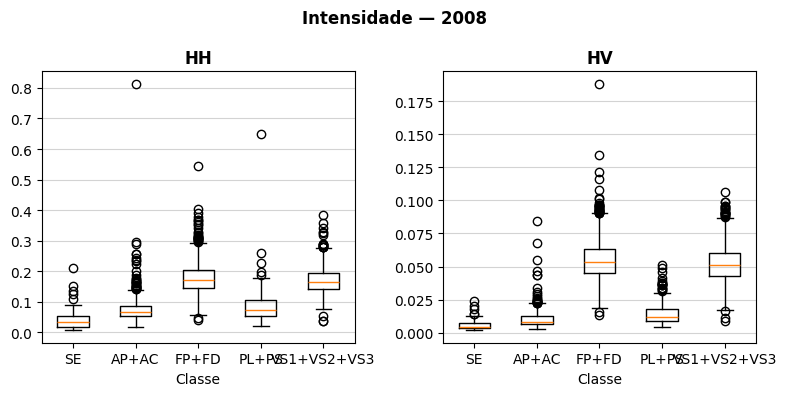

In [41]:
plots.boxplots_by_class(df, CLASSES, title=f'Intensidade — {DATA}', pdf=pdf)

## 4. Aderência e ENL

| Teste | Dados |
|---|---|
| Gama (α, β livres, MV) + KS | intensidade, por polarização |
| Normal (MV) + KS | intensidade e amplitude, por polarização |
| Mardia | intensidade e amplitude, bivariado |
| ENL iterativo | por polarização; o par de intensidades usa a média |


In [42]:
aderencia = []
for b in ['HH', 'HV']:
    aderencia.append(fit.gamma_fitting(df[['Class', b]], CLASSES, verbose=False).assign(Polarizacao=b, Formato='intensidade', Distribuicao='Gama'))
    aderencia.append(fit.normal_fitting(df[['Class', b]], CLASSES, verbose=False).assign(Polarizacao=b, Formato='intensidade', Distribuicao='Normal'))
    aderencia.append(fit.normal_fitting(df_a[['Class', b]], CLASSES, verbose=False).assign(Polarizacao=b, Formato='amplitude', Distribuicao='Normal'))
tabelas['aderencia_univariada'] = pd.concat(aderencia, ignore_index=True)
tabelas['mardia'] = pd.concat([fit.normal_fitting_mv(df, CLASSES).assign(Formato='intensidade'),
                               fit.normal_fitting_mv(df_a, CLASSES).assign(Formato='amplitude')], ignore_index=True)
pd.crosstab([tabelas['aderencia_univariada'].Distribuicao, tabelas['aderencia_univariada'].Formato,
             tabelas['aderencia_univariada'].Polarizacao], tabelas['aderencia_univariada'].H0)   # resumo (Tabelas 5.3 e 5.4)

ad = tabelas['aderencia_univariada']
colunas_teste = ['Distribuicao', 'Formato', 'Polarizacao']

# 1. Classes aceitas em cada teste
for (dist, formato, pol), g in ad.groupby(colunas_teste, sort=False):
    aceitas = g.loc[g['H0'] == 'accept', 'Class'].tolist()
    print(f'{dist:6s} | {formato:11s} | {pol}: {len(aceitas):2d}/{len(CLASSES)} aceitas -> {aceitas}')

# 2. Quadro classe x teste: p-valor com a decisão (✓ aceita H0, ✗ rejeita)
p_valor = ad.pivot_table(index='Class', columns=colunas_teste, values='p_value', aggfunc='first').reindex(CLASSES)
decisao = ad.pivot_table(index='Class', columns=colunas_teste, values='H0', aggfunc='first').reindex(CLASSES)
quadro = p_valor.map(lambda p: f'{p:.3g}') + decisao.map(lambda h: ' ✓' if h == 'accept' else ' ✗')
quadro.columns = [f'{d} {f} {b}' for d, f, b in quadro.columns]
tabelas['aderencia_por_classe'] = quadro.reset_index()       # vai para o 02_modelagem.xlsx
print('\nQuadro classe x teste (p-valor + decisão):')
display(quadro)

# 3. Mardia (bivariado HH+HV), por classe
print('\nMardia (bivariado HH+HV), por classe:')
display(tabelas['mardia'])



Gama   | intensidade | HH:  4/5 aceitas -> ['SE', 'FP+FD', 'PL+PS', 'VS1+VS2+VS3']
Normal | intensidade | HH:  0/5 aceitas -> []
Normal | amplitude   | HH:  3/5 aceitas -> ['SE', 'PL+PS', 'VS1+VS2+VS3']
Gama   | intensidade | HV:  2/5 aceitas -> ['FP+FD', 'VS1+VS2+VS3']
Normal | intensidade | HV:  0/5 aceitas -> []
Normal | amplitude   | HV:  2/5 aceitas -> ['FP+FD', 'VS1+VS2+VS3']

Quadro classe x teste (p-valor + decisão):


,Gama intensidade HH,Gama intensidade HV,Normal amplitude HH,Normal amplitude HV,Normal intensidade HH,Normal intensidade HV
Class,,,,,,
SE,0.0964 ✓,0.00166 ✗,0.0659 ✓,0.000282 ✗,0.000151 ✗,1.89e-07 ✗
AP+AC,0.00545 ✗,8.09e-06 ✗,0.000396 ✗,6.65e-07 ✗,1.4e-13 ✗,9.24e-18 ✗
FP+FD,0.207 ✓,0.729 ✓,0.0442 ✗,0.448 ✓,1.53e-05 ✗,0.00183 ✗
PL+PS,0.218 ✓,0.0065 ✗,0.0651 ✓,0.00116 ✗,2.61e-05 ✗,1.3e-07 ✗
VS1+VS2+VS3,0.648 ✓,0.49 ✓,0.601 ✓,0.298 ✓,0.0238 ✗,0.00794 ✗



Mardia (bivariado HH+HV), por classe:


,Class,skewness,p_value_skewness,kurtosis,p_value_kurtosis,H0,Formato
0,SE,735.484444,7.216143e-158,70.622750,0.000000e+00,reject,intensidade
1,AP+AC,11810.783175,0.000000e+00,591.157902,0.000000e+00,reject,intensidade
2,FP+FD,588.004772,6.112397e-126,51.103686,0.000000e+00,reject,intensidade
3,PL+PS,2181.895868,0.000000e+00,157.846984,0.000000e+00,reject,intensidade
4,VS1+VS2+VS3,142.308608,9.043583e-30,9.179604,4.326797e-20,reject,intensidade
5,SE,135.106342,3.148170e-28,11.830425,2.717608e-32,reject,amplitude
6,AP+AC,1663.062636,0.000000e+00,115.290196,0.000000e+00,reject,amplitude
7,FP+FD,66.439010,1.280048e-13,17.178321,3.859182e-66,reject,amplitude
8,PL+PS,270.729193,2.221286e-57,28.736275,1.344461e-181,reject,amplitude
9,VS1+VS2+VS3,20.080587,4.814337e-04,8.227605,1.909940e-16,reject,amplitude


In [43]:
ENL, enl_tabs = {}, []
for b in ['HH', 'HV']:
    r = fit.iterative_gamma_fitting(df[['Class', b]], CLASSES, verbose=False)
    if r is None:
        raise ValueError(f'ENL de {b} não determinado (nenhuma classe aderiu à Gama).')
    ENL[b] = r['best_enl']
    enl_tabs.append(r['fitting_result'].assign(Polarizacao=b))
    tabelas[f'enl_candidatos_{b}'] = r['result_counting']
ENL['media'] = 0.5 * (ENL['HH'] + ENL['HV'])
tabelas['enl_ajuste_final'] = pd.concat(enl_tabs, ignore_index=True)                  # Tabela 5.5
tabelas['enl'] = pd.DataFrame({'chave': list(ENL), 'ENL': list(ENL.values())})
print('\nENL (Effective Number of Looks) estimado por polarização e média:')
print({k: round(v, 4) for k, v in ENL.items()})


ENL (Effective Number of Looks) estimado por polarização e média:
{'HH': 16.5119, 'HV': 15.2746, 'media': 15.8933}


In [44]:
print('\nClasses aceitas na aderência à Gama (p-valor > 0.05) e ENL escolhido:')
ad = tabelas['aderencia_univariada']
for b in ['HH', 'HV']:
    livre = ad.query("Distribuicao == 'Gama' and Polarizacao == @b")[['Class', 'Alpha', 'p_value']]
    livre = livre.rename(columns={'Class': 'classe_origem', 'p_value': 'p_valor_livre'})
    cont = tabelas[f'enl_candidatos_{b}'].merge(livre, left_on='ENL', right_on='Alpha', how='left')
    print(f'\n{b} — ENL escolhido = {ENL[b]:.4f}')
    display(cont[['classe_origem', 'ENL', 'p_valor_livre', 'Count']])


Classes aceitas na aderência à Gama (p-valor > 0.05) e ENL escolhido:

HH — ENL escolhido = 16.5119


,classe_origem,ENL,p_valor_livre,Count
0,VS1+VS2+VS3,16.511925,0.648175,2
1,PL+PS,4.193262,0.217808,1
2,FP+FD,14.135607,0.207129,2
3,SE,2.532298,0.096389,1



HV — ENL escolhido = 15.2746


,classe_origem,ENL,p_valor_livre,Count
0,FP+FD,15.274619,0.729374,2
1,VS1+VS2+VS3,14.113081,0.489830,2


## 5. Separabilidade (opcional)

Bhattacharyya da Gama em cada polarização, com o ENL estimado, e dendrograma de Ward, como apoio à definição da legenda (Seção 4.3.1.3 da dissertação).

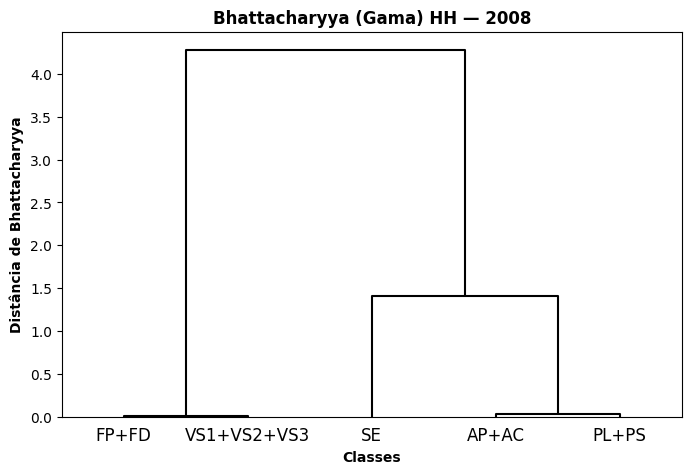

HH {'lvl_1': ['FP+FD', 'VS1+VS2+VS3'], 'lvl_2': ['AP+AC', 'PL+PS'], 'lvl_3': ['SE', 'AP+AC', 'PL+PS'], 'lvl_4': ['FP+FD', 'VS1+VS2+VS3', 'SE', 'AP+AC', 'PL+PS']}


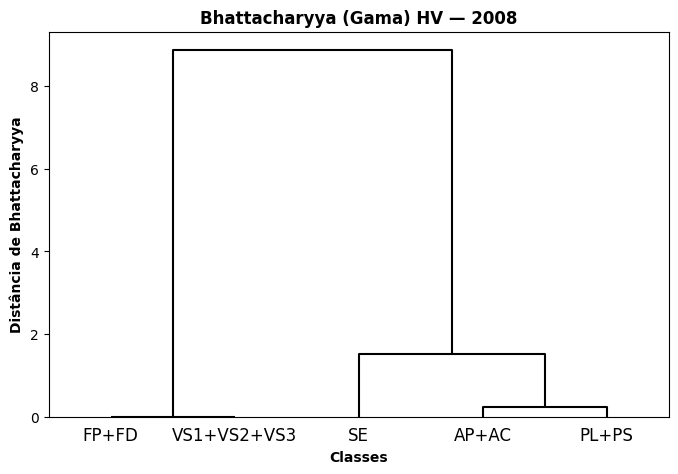

HV {'lvl_1': ['FP+FD', 'VS1+VS2+VS3'], 'lvl_2': ['AP+AC', 'PL+PS'], 'lvl_3': ['SE', 'AP+AC', 'PL+PS'], 'lvl_4': ['FP+FD', 'VS1+VS2+VS3', 'SE', 'AP+AC', 'PL+PS']}


In [45]:
if EXECUTAR_SEPARABILIDADE:
    for b in ['HH', 'HV']:
        B = sep.bhattacharyya_matrix(df[['Class', b]], CLASSES, 'gamma', ENL[b])
        tabelas[f'bhattacharyya_{b}'] = B.round(6).reset_index().rename(columns={'index': 'Classe'})
        Z = sep.hierarchical_clustering(B)
        plots.plot_dendrogram(Z, CLASSES, title=f'Bhattacharyya (Gama) {b} — {DATA}', pdf=pdf)
        print(b, sep.extract_hierarchy(Z, CLASSES))

## 6. Validação cruzada de cada modelo

São 70/30 estratificados, com `N_ITERACOES` repetições e agregação `NIVEL_AGREGACAO` na matriz de confusão. As sementes são 1..N, o que torna o processo reprodutível.

In [46]:
def enl_do_modelo(spec):
    e = spec['enl']
    return None if e is None else (ENL[e] if isinstance(e, str) else float(e))

cv = {}
for nome, spec in MODELOS.items():
    print(f'--- {nome}')
    cv[nome] = val.cross_validation(df[['Class'] + spec['atributos']], CLASSES, spec['distribuicao'],
                                    enl_do_modelo(spec), n_iterations=N_ITERACOES, train_proportion=PROP_TREINO,
                                    aggregation=AGREGACAO, normalize=NORMALIZAR_METRICAS,
                                    rank_by=CRITERIO_REPRESENTANTE, transform=spec['transformacao'], verbose=False)
    print(f"    OA média = {cv[nome]['overall_accuracy'].mean():.4f} | F1 macro médio = {cv[nome]['f1_macro'].mean():.4f}")

tabelas['validacao_global'], tabelas['validacao_classes'] = val.summarize_models(cv)
tabelas['validacao_iteracoes'] = val.iterations_table(cv)
tabelas['validacao_global'].round(4)

--- HH_gama
    OA média = 0.4785 | F1 macro médio = 0.4687
--- HV_gama
    OA média = 0.5065 | F1 macro médio = 0.4999
--- par_intensidade
    OA média = 0.5318 | F1 macro médio = 0.5282
--- HH_gauss_A
    OA média = 0.4807 | F1 macro médio = 0.4538
--- HV_gauss_A
    OA média = 0.5073 | F1 macro médio = 0.4971
--- gauss_biv_A
    OA média = 0.5414 | F1 macro médio = 0.5340


,Modelo,OA_media,OA_dp,OA_ci_lw,OA_ci_up,F1_media,F1_dp,F1_ci_lw,F1_ci_up,n_iteracoes
0,HH_gama,0.4785,0.0130,0.4540,0.5041,0.4687,0.0134,0.4426,0.4952,1000
1,HV_gama,0.5065,0.0131,0.4816,0.5332,0.4999,0.0135,0.4727,0.5257,1000
2,par_intensidade,0.5318,0.0130,0.5070,0.5579,0.5282,0.0136,0.5028,0.5541,1000
3,HH_gauss_A,0.4807,0.0129,0.4555,0.5060,0.4538,0.0134,0.4295,0.4807,1000
4,HV_gauss_A,0.5073,0.0127,0.4820,0.5330,0.4971,0.0132,0.4699,0.5238,1000
5,gauss_biv_A,0.5414,0.0132,0.5169,0.5673,0.5340,0.0134,0.5090,0.5599,1000


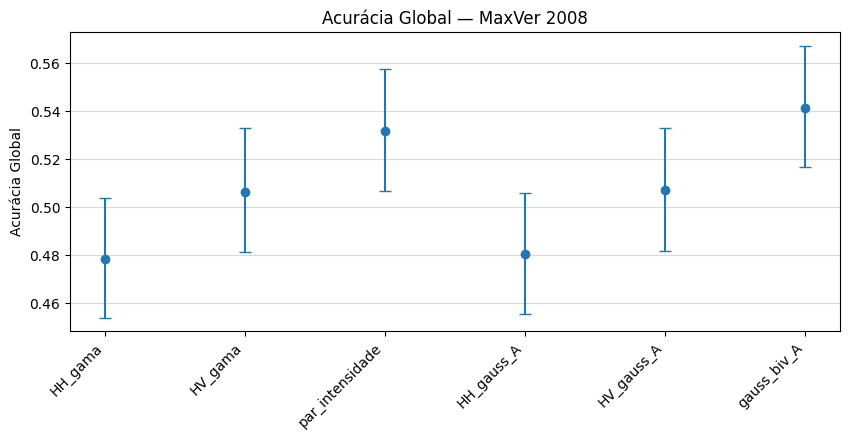

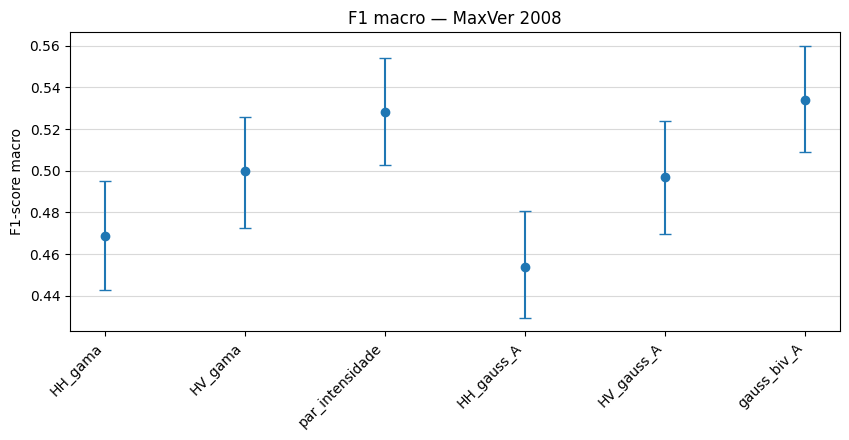

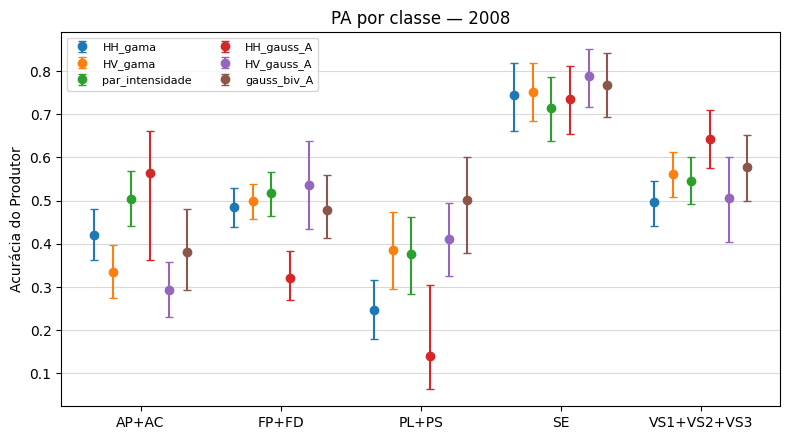

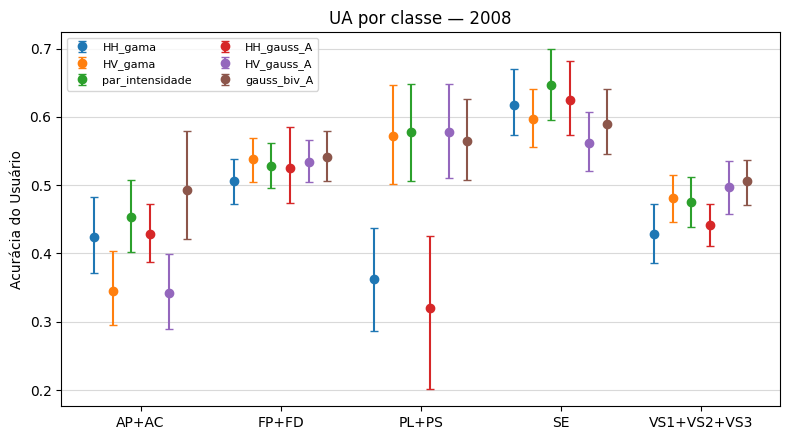

In [47]:
plots.plot_model_comparison(tabelas['validacao_global'], 'OA', title=f'Acurácia Global — MaxVer {DATA}', pdf=pdf)
plots.plot_model_comparison(tabelas['validacao_global'], 'F1', title=f'F1 macro — MaxVer {DATA}', pdf=pdf)
for metrica in ['PA', 'UA']:
    plots.plot_class_metrics(tabelas['validacao_classes'], metrica, title=f'{metrica} por classe — {DATA}', pdf=pdf)

## 7. Modelo representante de cada modelagem

O representante é a iteração cuja métrica `CRITERIO_REPRESENTANTE` está no **3º quartil**. A iteração é refeita exatamente com `reproduce_iteration`.

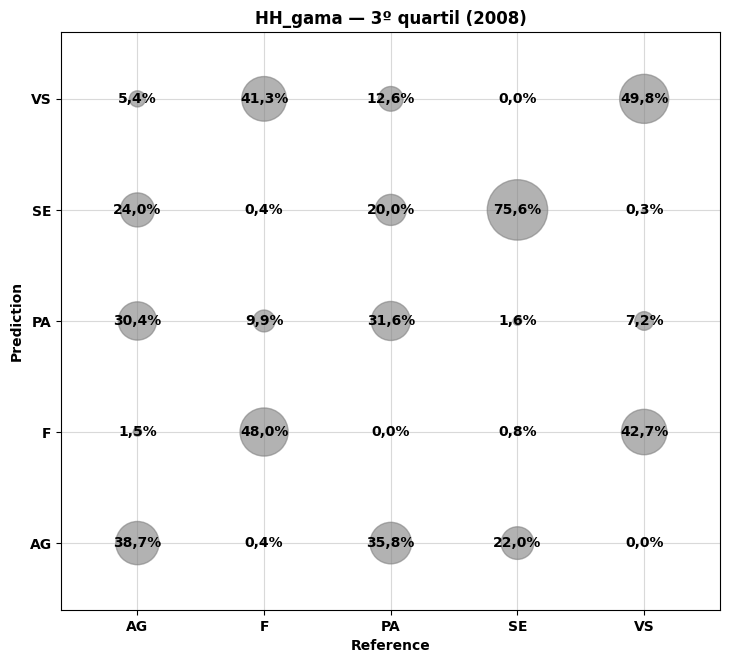

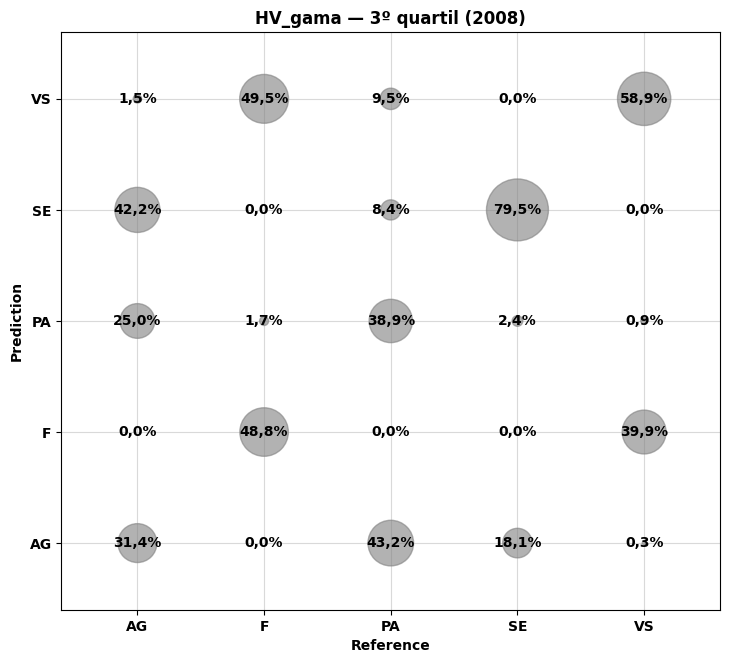

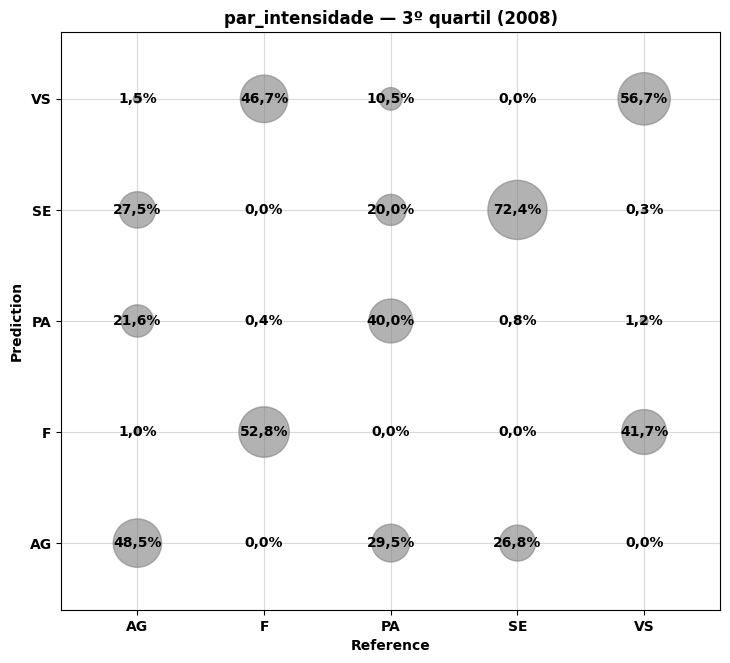

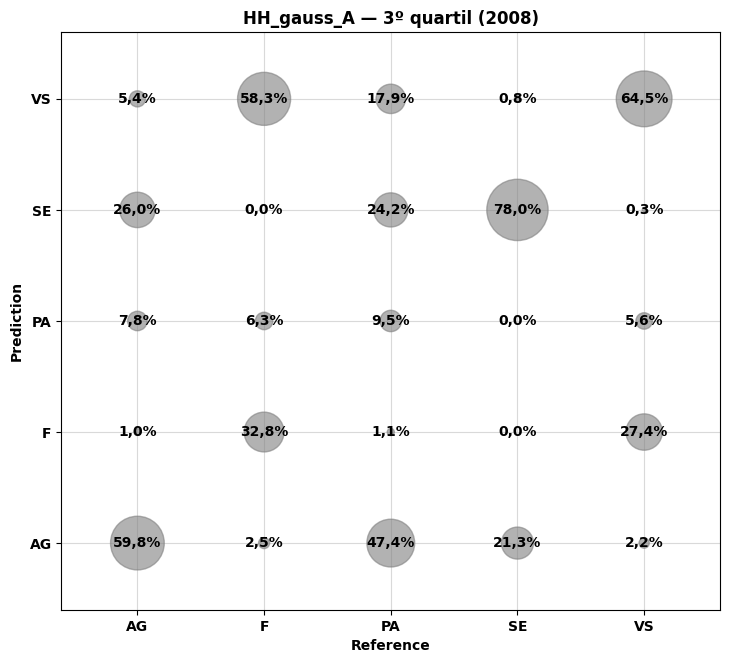

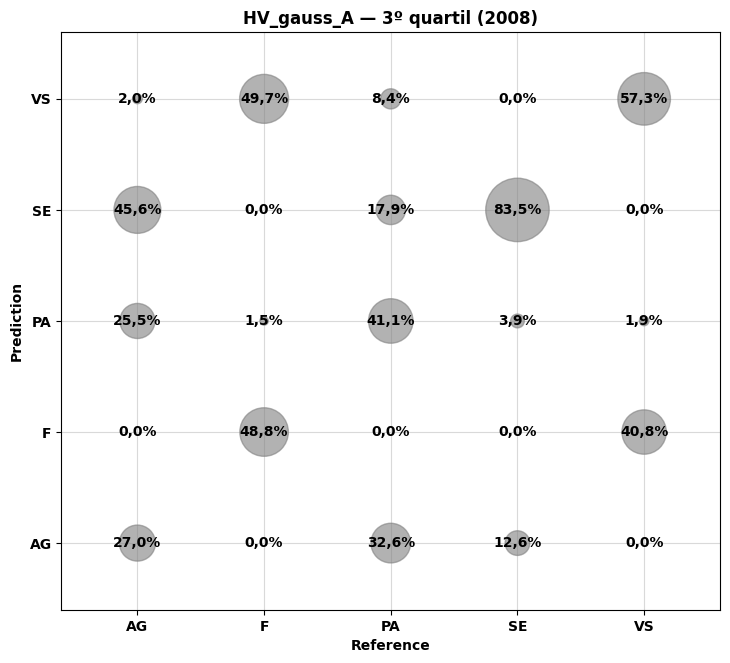

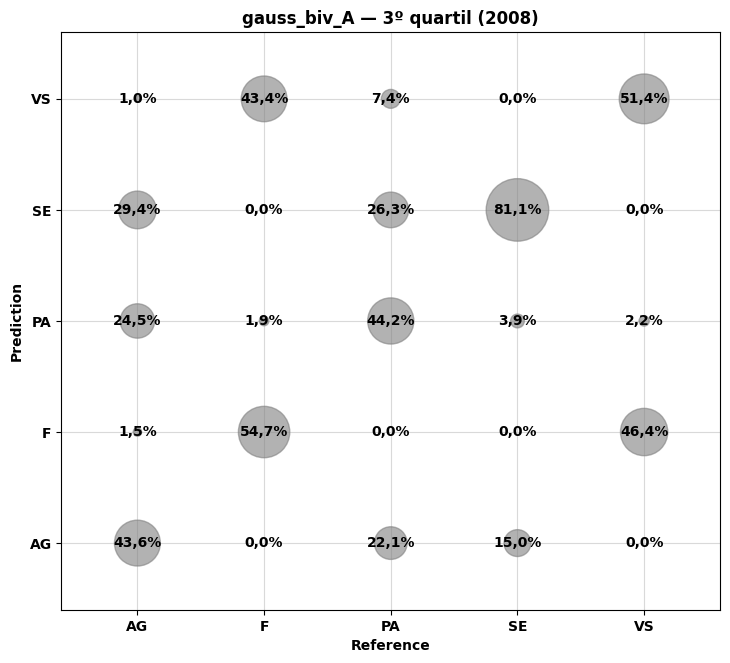

,Modelo,criterio,semente_3q,semente_mediana,semente_melhor,OA,F1_macro,ENL
0,HH_gama,overall_accuracy,451,345,909,0.4875,0.4807,16.5119
1,HV_gama,overall_accuracy,705,398,581,0.5151,0.5064,15.2746
2,par_intensidade,overall_accuracy,440,459,506,0.5410,0.5373,15.8933
3,HH_gauss_A,overall_accuracy,93,895,972,0.4891,0.4538,NaN
4,HV_gauss_A,overall_accuracy,4,481,581,0.5153,0.5008,NaN
5,gauss_biv_A,overall_accuracy,296,606,558,0.5502,0.5429,NaN


In [48]:
modelos, matrizes, representantes = {}, [], []
for nome, spec in MODELOS.items():
    sel = cv[nome]['selected']
    rep = val.reproduce_iteration(df[['Class'] + spec['atributos']], CLASSES, sel['third_quartile_seed'],
                                  spec['distribuicao'], enl_do_modelo(spec), train_proportion=PROP_TREINO,
                                  aggregation=AGREGACAO, normalize=NORMALIZAR_METRICAS, transform=spec['transformacao'])
    modelos[nome] = rep['model']
    representantes.append({'Modelo': nome, 'criterio': sel['rank_by'], 'semente_3q': sel['third_quartile_seed'],
                           'semente_mediana': sel['median_seed'], 'semente_melhor': sel['best_seed'],
                           'OA': rep['overall_accuracy'], 'F1_macro': rep['f1_macro'], 'ENL': enl_do_modelo(spec)})
    cm = rep['confusion_matrix'].rename(index=LEGENDA_FINAL, columns=LEGENDA_FINAL)
    matrizes.append(cm.stack().rename('n').reset_index().assign(Modelo=nome))
    plots.bubble_confusion_plot(cm, title=f'{nome} — 3º quartil ({DATA})', pdf=pdf)
tabelas['representantes'] = pd.DataFrame(representantes)
tabelas['matrizes_3q'] = pd.concat(matrizes, ignore_index=True)[['Modelo', 'Prediction', 'Reference', 'n']]
tabelas['representantes'].round(4)

## 8. Imagens de verossimilhança e classificação MaxVer

- **Verossimilhança:** um arquivo por modelo, com uma banda por classe e o nome da classe gravado na banda. É gravada em **log**, imune a *underflow*. O CMAP (notebook 03) lê esse formato com `tipo = 'log'`.
- **Classificação:** todos os modelos num único GeoTIFF, com uma banda por modelo e códigos de classe na ordem de `cfg['classes']`.

A transformação (amplitude) é aplicada automaticamente, porque fica gravada em cada modelo.

In [49]:
codigos = {c: i + 1 for i, c in enumerate(CLASSES)}
arquivos_verossimilhanca = {}
for nome, modelo in modelos.items():
    arquivos_verossimilhanca[nome] = rio.likelihood_raster(img['imagem'], modelo, OUT / 'verossimilhanca' / f'{nome}.tif',
                                                           band_names=BANDAS, log=True)
arq_maxver = rio.classification_stack(img['imagem'], modelos, OUT / 'maxver_modelos.tif', codigos, band_names=BANDAS)
tabelas['legenda_maxver'] = pd.DataFrame({'Classe': list(codigos), 'ID': list(codigos.values())})
print('Verossimilhanças:', *arquivos_verossimilhanca.values(), sep='\n  ')
print('Classificações MaxVer (1 banda por modelo):', arq_maxver)

Verossimilhanças:
  C:\cmap_python\resultados_python\2008\verossimilhanca\HH_gama.tif
  C:\cmap_python\resultados_python\2008\verossimilhanca\HV_gama.tif
  C:\cmap_python\resultados_python\2008\verossimilhanca\par_intensidade.tif
  C:\cmap_python\resultados_python\2008\verossimilhanca\HH_gauss_A.tif
  C:\cmap_python\resultados_python\2008\verossimilhanca\HV_gauss_A.tif
  C:\cmap_python\resultados_python\2008\verossimilhanca\gauss_biv_A.tif
Classificações MaxVer (1 banda por modelo): C:\cmap_python\resultados_python\2008\maxver_modelos.tif


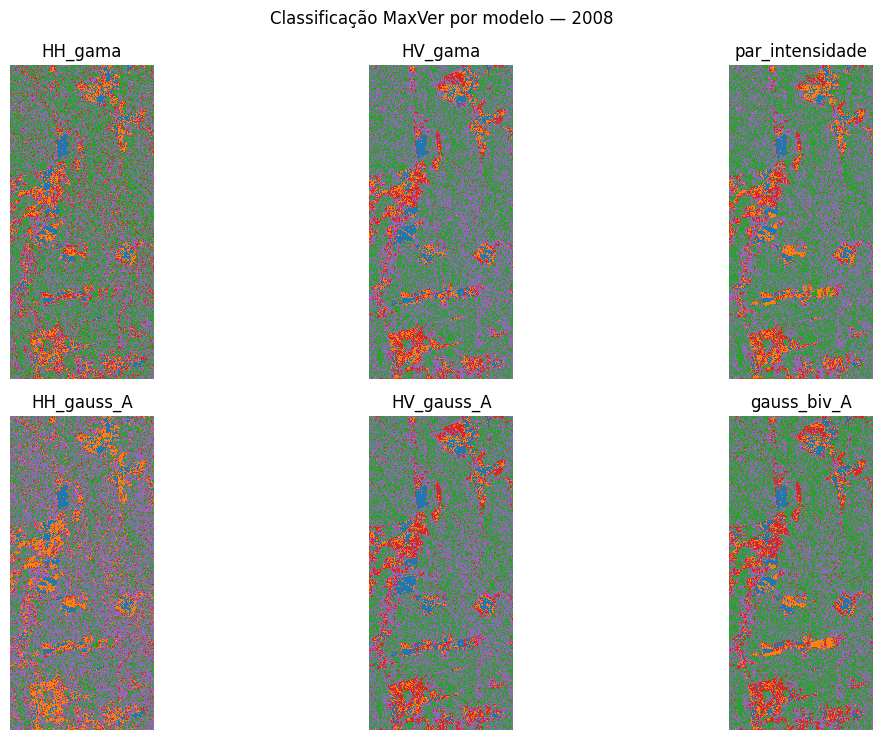

In [50]:
import rasterio
with rasterio.open(arq_maxver) as s:
    fig, axes = plt.subplots(2, (s.count + 1) // 2, figsize=(4.2 * ((s.count + 1) // 2), 7.5), squeeze=False)
    for ax, b in zip(axes.ravel(), range(1, s.count + 1)):
        ax.imshow(np.ma.masked_equal(s.read(b), 0), cmap='tab10', vmin=1, vmax=10, interpolation='nearest')
        ax.set_title(s.descriptions[b - 1]); ax.axis('off')
    for ax in axes.ravel()[s.count:]:
        ax.axis('off')
plt.suptitle(f'Classificação MaxVer por modelo — {DATA}'); plt.tight_layout()
if pdf: pdf.savefig(fig)
plt.show()

## 9. Gravação

In [ ]:
tabelas['parametros'] = pd.DataFrame({'parametro': ['DATA', 'N_ITERACOES', 'PROP_TREINO', 'NIVEL_AGREGACAO', 'NIVEL_GENERALIZACAO',
                                                     'RAZAO_DOWNSAMPLE', 'REMOVER_DUPLICADOS', 'CRITERIO_REPRESENTANTE',
                                                     'NORMALIZAR_METRICAS', 'BANDAS', 'MODELOS'],
                                       'valor': [DATA, N_ITERACOES, PROP_TREINO, NIVEL_AGREGACAO, NIVEL_GENERALIZACAO,
                                                 RAZAO_DOWNSAMPLE, REMOVER_DUPLICADOS, CRITERIO_REPRESENTANTE,
                                                 NORMALIZAR_METRICAS, str(BANDAS), json.dumps(MODELOS)]})
reporting.save_workbook(ARQ_PLANILHA, tabelas)
mdl.save_models(modelos, ARQ_MODELOS, extra={'data': DATA, 'ENL': ENL, 'codigos': codigos,
                                             'representantes': tabelas['representantes'].to_dict('records')})
if pdf: pdf.close()
print('Arquivos desta etapa:', *sorted(p.name for p in OUT.iterdir()), sep='\n  ')